# 07 - Forecasting Export Opportunity Demand

This notebook covers the forecasting part of the project **Forecasting and Identifying Global Export Opportunities for Algerian Exporters**. It is self-contained: the forecasting pipeline implementation is embedded directly in this notebook, and it uses the engineered `data/master_df.parquet` dataset without rebuilding raw BACI data.

Forecasting means estimating future destination-market demand for selected country-product pairs. In this project, the forecast is used as one input for export opportunity analysis and later for the dashboard.


## Why Forecast `partner_import_v`?

`partner_import_v` is the main target because it represents how much a destination country imports of a specific HS6 product. This is a demand-side signal: a market can be interesting for Algerian exporters even if Algeria has little or no current export presence there.

`alg_export_v` is kept as historical context. It helps show whether Algeria is already present in a market, but it is not the main demand forecast target.


## Non-Hydrocarbon Forecasting Scope

Algeria is already heavily dependent on hydrocarbons. If the forecasting sample is selected only by the largest global or partner import values, products such as HS 270900 petroleum oils dominate the results. That makes the project look like a hydrocarbon forecasting project instead of an export diversification project.

For the default project view, obvious hydrocarbon products are excluded:

- HS codes starting with `27`.
- Product descriptions containing terms such as petroleum, oils, gas, coal, or bituminous.

The code still supports `INCLUDE_HYDROCARBONS = True` when a full all-products view is needed.


## Balanced Country-Product Sample

Instead of selecting only the top country-product pairs globally, the pipeline first selects top products and then selects top countries within each product. This prevents one product from dominating the forecasting sample and gives a more useful panel for diversification analysis.

Default configuration:

- `TOP_PRODUCTS = 50`
- `TOP_COUNTRIES_PER_PRODUCT = 10`
- `FORECAST_HORIZON = 3`
- `INCLUDE_HYDROCARBONS = False`


## Time-Based Split

Forecasting must respect time order. A random split would let future observations influence training and would make the evaluation too optimistic. This notebook uses the existing `split` column when available: `train` and `val` are used for fitting, and `test` is used for final evaluation. In this dataset, the test period is 2022-2023.


## Models and Metrics

The self-contained notebook pipeline compares baseline and machine learning models:

- Naive baseline: next value equals the last observed value.
- Moving average baseline: next value equals the recent three-year average.
- Trend-adjusted naive: last value adjusted by a clipped recent growth rate.
- Simple exponential smoothing when enough history exists.
- ARIMA if `statsmodels` is installed; otherwise skipped safely.
- Random Forest, Gradient Boosting, and HistGradientBoosting regressors using lag features.

Baselines are included because advanced models should be compared against simple, transparent forecasting rules.

Metrics include MAE, RMSE, MAPE, sMAPE, and WMAPE. MAPE is kept for familiarity, but it can be unstable when actual trade values are zero or very small. sMAPE and WMAPE are more useful safeguards for this type of trade data.


In [ ]:
# Self-contained forecasting pipeline implementation.
# The full implementation lives here so the notebook can be
# run independently from top to bottom.
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MASTER_PATH = PROJECT_ROOT / "data" / "master_df.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data" / "forecast_outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"

TOP_PRODUCTS = 50
TOP_COUNTRIES_PER_PRODUCT = 10
FORECAST_HORIZON = 3
INCLUDE_HYDROCARBONS = False
TARGET_COL = "partner_import_v"
HISTORICAL_EXPORT_COL = "alg_export_v"
MIN_YEARS_FOR_EXP_SMOOTHING = 4
MIN_YEARS_FOR_ARIMA = 8
RANDOM_STATE = 42
TREND_GROWTH_CLIP = (-0.20, 0.35)

HYDROCARBON_TERMS = ("petroleum", "oils", "gas", "coal", "bituminous")


@dataclass
class ForecastResult:
    final_forecasts: pd.DataFrame
    metrics: pd.DataFrame
    comparison: pd.DataFrame
    top_opportunities: pd.DataFrame
    priority_countries: pd.DataFrame
    priority_products: pd.DataFrame
    panel: pd.DataFrame
    selection_summary: dict[str, object]


def _existing_columns(columns: list[str], candidates: list[str]) -> list[str]:
    return [col for col in candidates if col in columns]


def _safe_mape(actual: pd.Series, predicted: pd.Series, min_actual: float = 1.0) -> float:
    actual = pd.to_numeric(actual, errors="coerce")
    predicted = pd.to_numeric(predicted, errors="coerce")
    mask = actual.notna() & predicted.notna() & (actual.abs() >= min_actual)
    if not mask.any():
        return np.nan
    return float((np.abs((actual[mask] - predicted[mask]) / actual[mask])).mean() * 100)


def _smape(actual: pd.Series, predicted: pd.Series) -> float:
    actual = pd.to_numeric(actual, errors="coerce")
    predicted = pd.to_numeric(predicted, errors="coerce")
    denom = actual.abs() + predicted.abs()
    mask = actual.notna() & predicted.notna() & (denom > 0)
    if not mask.any():
        return np.nan
    return float((2 * (actual[mask] - predicted[mask]).abs() / denom[mask]).mean() * 100)


def _wmape(actual: pd.Series, predicted: pd.Series) -> float:
    actual = pd.to_numeric(actual, errors="coerce")
    predicted = pd.to_numeric(predicted, errors="coerce")
    mask = actual.notna() & predicted.notna()
    denominator = actual[mask].abs().sum()
    if denominator == 0:
        return np.nan
    return float((actual[mask] - predicted[mask]).abs().sum() / denominator * 100)


def _minmax(series: pd.Series, clip_quantiles: tuple[float, float] | None = None) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if clip_quantiles is not None and values.notna().any():
        lower, upper = values.quantile(list(clip_quantiles))
        values = values.clip(lower=lower, upper=upper)
    if not values.notna().any():
        return pd.Series(np.nan, index=series.index)
    min_value = values.min()
    max_value = values.max()
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return pd.Series(0.5, index=series.index)
    return ((values - min_value) / (max_value - min_value)).clip(0, 1)


def _normalize_weights(components: dict[str, tuple[float, pd.Series]]) -> tuple[dict[str, float], pd.DataFrame]:
    usable = {name: (weight, series) for name, (weight, series) in components.items() if series.notna().any()}
    total_weight = sum(weight for weight, _ in usable.values())
    if total_weight == 0:
        raise ValueError("No usable ranking components were available.")
    normalized_weights = {name: weight / total_weight for name, (weight, _) in usable.items()}
    component_frame = pd.DataFrame({name: series.fillna(0.5) for name, (_, series) in usable.items()})
    return normalized_weights, component_frame


def _metrics(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual = pd.to_numeric(actual, errors="coerce")
    predicted = pd.to_numeric(predicted, errors="coerce")
    mask = actual.notna() & predicted.notna()
    if not mask.any():
        return {"MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan, "sMAPE": np.nan, "WMAPE": np.nan}
    err = actual[mask] - predicted[mask]
    return {
        "MAE": float(np.abs(err).mean()),
        "RMSE": float(np.sqrt(np.square(err).mean())),
        "MAPE": _safe_mape(actual[mask], predicted[mask]),
        "sMAPE": _smape(actual[mask], predicted[mask]),
        "WMAPE": _wmape(actual[mask], predicted[mask]),
    }


def _is_hydrocarbon_frame(df: pd.DataFrame) -> pd.Series:
    k_is_hs27 = df["k"].astype(str).str.startswith("27")
    if "description_short" in df.columns:
        desc = df["description_short"].astype(str).str.lower()
        term_match = desc.str.contains("|".join(HYDROCARBON_TERMS), regex=True, na=False)
    else:
        term_match = pd.Series(False, index=df.index)
    return k_is_hs27 | term_match


def load_master_subset(master_path: Path = MASTER_PATH) -> pd.DataFrame:
    if not master_path.exists():
        raise FileNotFoundError(f"Master dataset not found: {master_path}")

    schema_cols = pq.ParquetFile(master_path).schema.names
    required = ["t", "j", "k", TARGET_COL]
    missing = [col for col in required if col not in schema_cols]
    if missing:
        raise ValueError(f"Missing required forecasting columns: {missing}")

    optional = [
        "iso3",
        "country_name",
        "description_short",
        "split",
        "world_import_v",
        HISTORICAL_EXPORT_COL,
        "world_demand_growth",
        "global_demand_log",
        "global_demand_rank",
        "market_penetration",
        "rca",
        "label_opportunity",
    ]
    columns = required + _existing_columns(schema_cols, optional)
    df = pd.read_parquet(master_path, columns=columns, engine="pyarrow")

    df["t"] = pd.to_numeric(df["t"], errors="coerce").astype("Int64")
    df["j"] = pd.to_numeric(df["j"], errors="coerce").astype("Int64")
    df["k"] = df["k"].astype(str)
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).clip(lower=0)
    if HISTORICAL_EXPORT_COL in df.columns:
        df[HISTORICAL_EXPORT_COL] = pd.to_numeric(df[HISTORICAL_EXPORT_COL], errors="coerce").fillna(0).clip(lower=0)
    for col in _existing_columns(
        df.columns.tolist(),
        [
            "world_import_v",
            "world_demand_growth",
            "global_demand_log",
            "global_demand_rank",
            "market_penetration",
            "rca",
            "label_opportunity",
        ],
    ):
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "country_name" not in df.columns:
        df["country_name"] = df["iso3"] if "iso3" in df.columns else df["j"].astype(str)
    if "description_short" not in df.columns:
        df["description_short"] = df["k"].astype(str)
    if "iso3" not in df.columns:
        df["iso3"] = df["j"].astype(str)

    df = df.dropna(subset=["t", "j", "k"]).copy()
    df["t"] = df["t"].astype(int)
    df["j"] = df["j"].astype(int)
    df["is_hydrocarbon"] = _is_hydrocarbon_frame(df)
    return df


def prepare_balanced_series(
    df: pd.DataFrame,
    top_products: int = TOP_PRODUCTS,
    top_countries_per_product: int = TOP_COUNTRIES_PER_PRODUCT,
    include_hydrocarbons: bool = INCLUDE_HYDROCARBONS,
) -> tuple[pd.DataFrame, dict[str, object]]:
    scoped = df.copy()
    forecast_scope = "all_products_including_hydrocarbons" if include_hydrocarbons else "non_hydrocarbon_diversification"
    if not include_hydrocarbons:
        scoped = scoped.loc[~scoped["is_hydrocarbon"]].copy()
    if scoped.empty:
        raise ValueError("No rows remain after hydrocarbon filtering. Set include_hydrocarbons=True.")

    demand_col = TARGET_COL
    product_totals = (
        scoped.groupby(["k", "description_short"], observed=True)[demand_col]
        .sum()
        .sort_values(ascending=False)
        .head(top_products)
        .reset_index()
    )
    selected_products = product_totals["k"].tolist()
    product_scoped = scoped.loc[scoped["k"].isin(selected_products)].copy()

    pair_totals = (
        product_scoped.groupby(["k", "j"], observed=True)[demand_col]
        .sum()
        .reset_index(name="series_demand")
    )
    selected_pairs = (
        pair_totals.sort_values(["k", "series_demand"], ascending=[True, False])
        .groupby("k", observed=True)
        .head(top_countries_per_product)[["k", "j"]]
    )

    panel_raw = product_scoped.merge(selected_pairs, on=["k", "j"], how="inner")
    agg: dict[str, str] = {TARGET_COL: "sum"}
    for col in [
        HISTORICAL_EXPORT_COL,
        "world_import_v",
        "world_demand_growth",
        "global_demand_log",
        "global_demand_rank",
        "market_penetration",
        "rca",
        "label_opportunity",
        "is_hydrocarbon",
    ]:
        if col in panel_raw.columns:
            agg[col] = "mean" if col != "is_hydrocarbon" else "max"
    for col in ["iso3", "country_name", "description_short"]:
        if col in panel_raw.columns:
            agg[col] = "first"
    if "split" in panel_raw.columns:
        agg["split"] = "first"

    panel = (
        panel_raw.groupby(["j", "k", "t"], observed=True)
        .agg(agg)
        .reset_index()
        .sort_values(["k", "j", "t"])
        .reset_index(drop=True)
    )
    panel["series_id"] = panel["j"].astype(str) + "__" + panel["k"].astype(str)
    panel["forecast_scope"] = forecast_scope
    panel["is_hydrocarbon"] = panel["is_hydrocarbon"].astype(bool)

    top_product_table = (
        panel.groupby(["k", "description_short"], observed=True)[TARGET_COL]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    summary = {
        "forecast_scope": forecast_scope,
        "include_hydrocarbons": include_hydrocarbons,
        "selected_countries": int(panel["j"].nunique()),
        "selected_products": int(panel["k"].nunique()),
        "selected_series": int(panel["series_id"].nunique()),
        "top_selected_products": top_product_table,
    }
    return panel, summary


def add_lag_features(panel: pd.DataFrame) -> pd.DataFrame:
    panel = panel.sort_values(["series_id", "t"]).copy()
    group = panel.groupby("series_id", observed=True)[TARGET_COL]
    for lag in [1, 2, 3]:
        panel[f"target_lag_{lag}"] = group.shift(lag)
    panel["rolling_mean_3"] = (
        group.shift(1)
        .groupby(panel["series_id"], observed=True)
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    panel["growth_rate_lag_1"] = group.pct_change().replace([np.inf, -np.inf], np.nan).shift(1)
    panel["year"] = panel["t"]
    panel["series_code"] = pd.factorize(panel["series_id"])[0]
    panel["country_code"] = pd.factorize(panel["j"])[0]
    panel["product_code"] = pd.factorize(panel["k"])[0]
    return panel


def _train_test_masks(panel: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    if "split" in panel.columns and panel["split"].notna().any():
        train_mask = panel["split"].isin(["train", "val"])
        test_mask = panel["split"].eq("test")
    else:
        train_mask = panel["t"] <= 2021
        test_mask = panel["t"] >= 2022
    return train_mask, test_mask


def _trend_growth_rate(values: list[float]) -> float:
    values = [float(v) for v in values if pd.notna(v)]
    if len(values) < 2:
        return 0.0
    recent = np.array(values[-4:], dtype=float)
    changes = []
    for prev, curr in zip(recent[:-1], recent[1:]):
        if prev > 0:
            changes.append((curr - prev) / prev)
    if changes:
        growth = float(np.median(changes))
    else:
        first_positive = next((v for v in recent[:-1] if v > 0), None)
        growth = ((recent[-1] / first_positive) ** (1 / (len(recent) - 1)) - 1) if first_positive else 0.0
    return float(np.clip(growth, TREND_GROWTH_CLIP[0], TREND_GROWTH_CLIP[1]))


def baseline_predictions(panel: pd.DataFrame) -> pd.DataFrame:
    train_mask, test_mask = _train_test_masks(panel)
    test_years = sorted(panel.loc[test_mask, "t"].unique().tolist())
    rows: list[dict] = []
    arima_available = False
    try:
        from statsmodels.tsa.arima.model import ARIMA  # type: ignore

        arima_available = True
    except Exception:
        ARIMA = None

    for series_id, group in panel.groupby("series_id", observed=True):
        group = group.sort_values("t").copy()
        meta = group.iloc[-1][["j", "k", "iso3", "country_name", "description_short"]].to_dict()
        history = group.loc[train_mask.reindex(group.index, fill_value=False), ["t", TARGET_COL]]
        for year in test_years:
            actual_row = group.loc[group["t"].eq(year)]
            if actual_row.empty or history.empty:
                continue
            actual = float(actual_row[TARGET_COL].iloc[0])
            values = history[TARGET_COL].astype(float).tolist()
            growth = _trend_growth_rate(values)
            candidate_rows = [
                ("naive_last_value", values[-1]),
                ("moving_average_3", float(np.mean(values[-3:]))),
                ("trend_adjusted_naive", values[-1] * (1 + growth)),
            ]
            if len(values) >= MIN_YEARS_FOR_EXP_SMOOTHING:
                level = values[0]
                alpha = 0.5
                for value in values[1:]:
                    level = alpha * value + (1 - alpha) * level
                candidate_rows.append(("simple_exponential_smoothing", level))
            if arima_available and len(values) >= MIN_YEARS_FOR_ARIMA:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        pred = ARIMA(np.log1p(values), order=(1, 1, 0)).fit().forecast(steps=1)[0]
                    candidate_rows.append(("arima_110_log", float(np.expm1(pred))))
                except Exception:
                    pass
            for model, pred in candidate_rows:
                rows.append(
                    {
                        **meta,
                        "series_id": series_id,
                        "t": int(year),
                        "actual": actual,
                        "model": model,
                        "prediction": max(float(pred), 0),
                    }
                )
            history = pd.concat([history, actual_row[["t", TARGET_COL]]], ignore_index=True)

    out = pd.DataFrame(rows)
    if not arima_available:
        out.attrs["arima_note"] = "statsmodels is not installed; ARIMA/SARIMAX skipped safely."
    return out


def train_ml_models(panel_features: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, object], list[str]]:
    train_mask, test_mask = _train_test_masks(panel_features)
    base_features = [
        "target_lag_1",
        "target_lag_2",
        "target_lag_3",
        "rolling_mean_3",
        "growth_rate_lag_1",
        "year",
        "series_code",
        "country_code",
        "product_code",
    ]
    optional_features = _existing_columns(
        panel_features.columns.tolist(),
        ["global_demand_rank", "world_demand_growth", "market_penetration", "rca"],
    )
    features = base_features + optional_features
    model_frame = panel_features.dropna(subset=["target_lag_1", "target_lag_2", "target_lag_3"]).copy()
    for col in features:
        model_frame[col] = pd.to_numeric(model_frame[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        fill_value = model_frame[col].median()
        model_frame[col] = model_frame[col].fillna(0 if pd.isna(fill_value) else fill_value)

    train_df = model_frame.loc[train_mask.reindex(model_frame.index, fill_value=False)].copy()
    test_df = model_frame.loc[test_mask.reindex(model_frame.index, fill_value=False)].copy()
    if train_df.empty or test_df.empty:
        raise ValueError("Not enough lagged rows for ML forecasting train/test split.")

    models: dict[str, object] = {
        "random_forest": RandomForestRegressor(
            n_estimators=180,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "gradient_boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "hist_gradient_boosting": HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            max_iter=250,
            learning_rate=0.05,
            l2_regularization=0.01,
        ),
    }

    predictions = []
    x_train = train_df[features]
    y_train = np.log1p(train_df[TARGET_COL])
    x_test = test_df[features]
    for model_name, model in models.items():
        model.fit(x_train, y_train)
        pred = np.clip(np.expm1(model.predict(x_test)), 0, None)
        temp = test_df[["series_id", "j", "k", "iso3", "country_name", "description_short", "t", TARGET_COL]].copy()
        temp = temp.rename(columns={TARGET_COL: "actual"})
        temp["model"] = model_name
        temp["prediction"] = pred
        predictions.append(temp)

    return pd.concat(predictions, ignore_index=True), models, features


def _select_future_strategy(metrics: pd.DataFrame) -> tuple[str, str]:
    best_model = metrics.dropna(subset=["RMSE"]).sort_values("RMSE").iloc[0]["model"]
    if best_model in {"naive_last_value", "moving_average_3", "simple_exponential_smoothing"}:
        return best_model, "trend_adjusted_naive"
    return best_model, best_model


def future_forecasts(
    panel_features: pd.DataFrame,
    future_model_name: str,
    models: dict[str, object],
    features: list[str],
    horizon: int = FORECAST_HORIZON,
) -> pd.DataFrame:
    max_year = int(panel_features["t"].max())
    rows = []

    for _, group in panel_features.groupby("series_id", observed=True):
        group = group.sort_values("t").copy()
        latest = group.iloc[-1]
        history = group[TARGET_COL].astype(float).tolist()
        latest_actual = float(history[-1]) if history else 0.0
        latest_alg_export = float(latest.get(HISTORICAL_EXPORT_COL, 0) or 0)
        growth = _trend_growth_rate(history)

        for step in range(1, horizon + 1):
            forecast_year = max_year + step
            lag_1 = history[-1] if len(history) >= 1 else 0.0
            lag_2 = history[-2] if len(history) >= 2 else 0.0
            lag_3 = history[-3] if len(history) >= 3 else 0.0
            row = {
                "year": forecast_year,
                "t": forecast_year,
                "country_name": latest["country_name"],
                "iso3": latest["iso3"],
                "j": int(latest["j"]),
                "k": latest["k"],
                "description_short": latest["description_short"],
                "historical_partner_import_v": latest_actual,
                "latest_alg_export_v": latest_alg_export,
                "market_penetration": latest.get("market_penetration", np.nan),
                "rca": latest.get("rca", np.nan),
                "global_demand_rank": latest.get("global_demand_rank", np.nan),
                "forecast_horizon": step,
                "is_hydrocarbon": bool(latest.get("is_hydrocarbon", False)),
                "forecast_scope": latest.get("forecast_scope", ""),
                "series_id": latest["series_id"],
            }
            if future_model_name == "trend_adjusted_naive":
                pred = lag_1 * ((1 + growth) ** step)
                model_label = "trend_adjusted_naive"
            elif future_model_name == "moving_average_3":
                pred = float(np.mean(history[-3:]))
                model_label = "moving_average_3"
            elif future_model_name in models:
                feature_row = {
                    **latest.to_dict(),
                    "t": forecast_year,
                    "year": forecast_year,
                    "target_lag_1": lag_1,
                    "target_lag_2": lag_2,
                    "target_lag_3": lag_3,
                    "rolling_mean_3": float(np.mean(history[-3:])),
                    "growth_rate_lag_1": growth,
                }
                x = pd.DataFrame([feature_row])
                for col in features:
                    x[col] = pd.to_numeric(x[col], errors="coerce").fillna(0)
                pred = float(np.expm1(models[future_model_name].predict(x[features])[0]))
                model_label = future_model_name
            else:
                pred = lag_1
                model_label = "naive_last_value"

            pred = max(float(pred), 0)
            row["forecast_partner_import_v"] = pred
            row["predicted_growth_abs"] = pred - latest_actual
            row["predicted_growth_pct"] = ((pred - latest_actual) / latest_actual * 100) if latest_actual > 0 else np.nan
            row["model"] = model_label
            history.append(pred)
            rows.append(row)

    clean_cols = [
        "year",
        "t",
        "country_name",
        "iso3",
        "j",
        "k",
        "description_short",
        "historical_partner_import_v",
        "forecast_partner_import_v",
        "latest_alg_export_v",
        "market_penetration",
        "rca",
        "global_demand_rank",
        "predicted_growth_abs",
        "predicted_growth_pct",
        "forecast_horizon",
        "model",
        "is_hydrocarbon",
        "forecast_scope",
        "series_id",
    ]
    return pd.DataFrame(rows)[clean_cols]


def _opportunity_reason(row: pd.Series) -> str:
    reasons = []
    if row.get("normalized_forecasted_demand", 0) >= 0.70:
        reasons.append("high forecasted demand")
    if row.get("normalized_predicted_growth_rate", 0) >= 0.60:
        reasons.append("positive predicted growth")
    if row.get("normalized_global_demand_rank", 0) >= 0.60:
        reasons.append("strong global demand")
    if row.get("normalized_rca", 0) >= 0.60:
        reasons.append("relatively strong Algeria RCA signal")
    if row.get("low_market_penetration_score", 0) >= 0.60:
        reasons.append("low current Algerian market penetration")
    if not reasons:
        return "Moderate forecast opportunity based on available demand, growth, and market-position indicators."
    text = ", ".join(reasons)
    return text[:1].upper() + text[1:] + "."


def build_forecast_opportunity_ranking(
    final_forecasts: pd.DataFrame | Path,
    output_dir: Path = OUTPUT_DIR,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, str]:
    if isinstance(final_forecasts, (str, Path)):
        forecasts = pd.read_csv(final_forecasts)
    else:
        forecasts = final_forecasts.copy()
    output_dir.mkdir(parents=True, exist_ok=True)

    required = [
        "year",
        "t",
        "country_name",
        "iso3",
        "j",
        "k",
        "description_short",
        "forecast_partner_import_v",
        "historical_partner_import_v",
        "latest_alg_export_v",
        "predicted_growth_abs",
        "forecast_horizon",
        "model",
        "is_hydrocarbon",
        "forecast_scope",
    ]
    missing = [col for col in required if col not in forecasts.columns]
    if missing:
        raise ValueError(f"Missing required final forecast columns for ranking: {missing}")

    for col in [
        "forecast_partner_import_v",
        "historical_partner_import_v",
        "latest_alg_export_v",
        "predicted_growth_abs",
        "predicted_growth_pct",
        "global_demand_rank",
        "rca",
        "market_penetration",
    ]:
        if col in forecasts.columns:
            forecasts[col] = pd.to_numeric(forecasts[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    if "predicted_growth_pct" not in forecasts.columns:
        forecasts["predicted_growth_pct"] = np.where(
            forecasts["historical_partner_import_v"] > 0,
            forecasts["predicted_growth_abs"] / forecasts["historical_partner_import_v"] * 100,
            np.nan,
        )
    for col in ["global_demand_rank", "rca", "market_penetration"]:
        if col not in forecasts.columns:
            forecasts[col] = np.nan

    if "is_hydrocarbon" in forecasts.columns:
        hydrocarbon_mask = forecasts["is_hydrocarbon"].astype(str).str.lower().isin(["true", "1", "yes"])
        forecasts = forecasts.loc[~hydrocarbon_mask].copy()

    components = {
        "normalized_forecasted_demand": (
            0.40,
            _minmax(forecasts["forecast_partner_import_v"].clip(lower=0), clip_quantiles=(0.01, 0.99)),
        ),
        "normalized_predicted_growth_rate": (
            0.25,
            _minmax(forecasts["predicted_growth_pct"], clip_quantiles=(0.05, 0.95)),
        ),
        "normalized_global_demand_rank": (
            0.20,
            pd.to_numeric(forecasts["global_demand_rank"], errors="coerce").clip(0, 1),
        ),
        "normalized_rca": (
            0.10,
            _minmax(forecasts["rca"].clip(lower=0), clip_quantiles=(0.01, 0.99)),
        ),
        "low_market_penetration_score": (
            0.05,
            1 - pd.to_numeric(forecasts["market_penetration"], errors="coerce").clip(0, 1),
        ),
    }
    actual_weights, component_frame = _normalize_weights(components)
    for col in component_frame.columns:
        forecasts[col] = component_frame[col]
    forecasts["low_market_penetration_score"] = forecasts.get("low_market_penetration_score", pd.Series(0.5, index=forecasts.index))
    forecasts["forecast_opportunity_score"] = 0.0
    for name, weight in actual_weights.items():
        forecasts["forecast_opportunity_score"] += forecasts[name] * weight
    forecasts["forecast_opportunity_score"] = forecasts["forecast_opportunity_score"].clip(0, 1)

    forecasts["reason_or_interpretation"] = forecasts.apply(_opportunity_reason, axis=1)
    ranked = forecasts.rename(
        columns={
            "forecast_partner_import_v": "forecasted_value",
            "historical_partner_import_v": "latest_historical_demand",
            "model": "model_used",
        }
    ).sort_values(
        ["forecast_opportunity_score", "forecasted_value", "predicted_growth_abs"],
        ascending=False,
    )
    ranked.insert(0, "rank", range(1, len(ranked) + 1))

    ranking_cols = [
        "rank",
        "year",
        "forecast_horizon",
        "country_name",
        "iso3",
        "j",
        "k",
        "description_short",
        "forecasted_value",
        "latest_historical_demand",
        "latest_alg_export_v",
        "predicted_growth_abs",
        "predicted_growth_pct",
        "global_demand_rank",
        "rca",
        "market_penetration",
        "low_market_penetration_score",
        "forecast_opportunity_score",
        "model_used",
        "is_hydrocarbon",
        "forecast_scope",
        "reason_or_interpretation",
    ]
    ranked = ranked[ranking_cols]

    high_threshold = ranked["forecast_opportunity_score"].quantile(0.75)
    high = ranked["forecast_opportunity_score"] >= high_threshold
    priority_countries = (
        ranked.assign(high_opportunity=high)
        .groupby(["country_name", "iso3", "j"], observed=True)
        .agg(
            average_opportunity_score=("forecast_opportunity_score", "mean"),
            total_forecasted_value=("forecasted_value", "sum"),
            total_predicted_growth=("predicted_growth_abs", "sum"),
            high_opportunity_products=("high_opportunity", "sum"),
            ranked_opportunities=("forecast_opportunity_score", "size"),
        )
        .reset_index()
        .sort_values(
            ["average_opportunity_score", "total_forecasted_value", "total_predicted_growth"],
            ascending=False,
        )
        .reset_index(drop=True)
    )
    priority_countries.insert(0, "rank", range(1, len(priority_countries) + 1))

    priority_products = (
        ranked.assign(high_opportunity=high)
        .groupby(["k", "description_short"], observed=True)
        .agg(
            average_opportunity_score=("forecast_opportunity_score", "mean"),
            total_forecasted_value=("forecasted_value", "sum"),
            total_predicted_growth=("predicted_growth_abs", "sum"),
            high_opportunity_countries=("high_opportunity", "sum"),
            ranked_opportunities=("forecast_opportunity_score", "size"),
        )
        .reset_index()
        .sort_values(
            ["average_opportunity_score", "total_forecasted_value", "total_predicted_growth"],
            ascending=False,
        )
        .reset_index(drop=True)
    )
    priority_products.insert(0, "rank", range(1, len(priority_products) + 1))

    formula = " + ".join(f"{weight:.3f}*{name}" for name, weight in actual_weights.items())
    ranked.to_csv(output_dir / "top_forecasted_opportunities.csv", index=False)
    priority_countries.to_csv(output_dir / "priority_countries.csv", index=False)
    priority_products.to_csv(output_dir / "priority_products.csv", index=False)
    return ranked, priority_countries, priority_products, formula


def make_plots(
    panel: pd.DataFrame,
    comparison: pd.DataFrame,
    final_forecasts: pd.DataFrame,
    metrics: pd.DataFrame,
    plots_dir: Path = PLOTS_DIR,
) -> None:
    plots_dir.mkdir(parents=True, exist_ok=True)
    best_model = metrics.dropna(subset=["RMSE"]).sort_values("RMSE").iloc[0]["model"]
    sample_series = (
        final_forecasts.groupby("series_id", observed=True)["forecast_partner_import_v"]
        .sum()
        .sort_values(ascending=False)
        .head(3)
        .index
    )

    plt.figure(figsize=(12, 6))
    for series_id in sample_series:
        hist = panel.loc[panel["series_id"].eq(series_id)].sort_values("t")
        fut = final_forecasts.loc[final_forecasts["series_id"].eq(series_id)].sort_values("t")
        label = hist["country_name"].iloc[-1] + " | " + str(hist["description_short"].iloc[-1])[:32]
        plt.plot(hist["t"], hist[TARGET_COL], marker="o", label=f"Historical: {label}")
        plt.plot(fut["t"], fut["forecast_partner_import_v"], marker="x", linestyle="--", label=f"Forecast: {label}")
    plt.title("Historical vs Forecasted Partner Import Demand")
    plt.xlabel("Year")
    plt.ylabel("Partner import value")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(plots_dir / "historical_vs_forecasted_demand.png", dpi=160)
    plt.close()

    best_comp = comparison.loc[comparison["model"].eq(best_model)].copy()
    plt.figure(figsize=(7, 7))
    plt.scatter(best_comp["actual"], best_comp["prediction"], alpha=0.55)
    limit = max(best_comp["actual"].max(), best_comp["prediction"].max())
    plt.plot([0, limit], [0, limit], color="black", linewidth=1)
    plt.title("Actual vs Predicted Demand on Test Years")
    plt.xlabel("Actual partner import value")
    plt.ylabel("Predicted partner import value")
    plt.tight_layout()
    plt.savefig(plots_dir / "actual_vs_predicted_test_years.png", dpi=160)
    plt.close()

    horizon_last = final_forecasts.sort_values("forecast_horizon").groupby("series_id", observed=True).tail(1)
    country_growth = horizon_last.groupby("country_name", observed=True)["predicted_growth_abs"].sum().sort_values(ascending=False)
    if (country_growth > 0).any():
        country_growth = country_growth[country_growth > 0].head(15)
        title_suffix = "Positive Growth"
    else:
        country_growth = country_growth.head(15)
        title_suffix = "Least Negative or Stable"
    plt.figure(figsize=(10, 6))
    country_growth.sort_values().plot(kind="barh")
    plt.title(f"Top Predicted Growth Countries ({title_suffix})")
    plt.xlabel("Predicted demand growth")
    plt.tight_layout()
    plt.savefig(plots_dir / "top_predicted_growth_countries.png", dpi=160)
    plt.close()

    product_growth = (
        horizon_last.groupby(["k", "description_short"], observed=True)["predicted_growth_abs"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    if (product_growth["predicted_growth_abs"] > 0).any():
        product_growth = product_growth.loc[product_growth["predicted_growth_abs"] > 0].head(15)
        title_suffix = "Positive Growth"
    else:
        product_growth = product_growth.head(15)
        title_suffix = "Least Negative or Stable"
    product_growth["label"] = product_growth["k"].astype(str) + " - " + product_growth["description_short"].astype(str).str.slice(0, 42)
    plt.figure(figsize=(11, 7))
    plt.barh(product_growth["label"][::-1], product_growth["predicted_growth_abs"][::-1])
    plt.title(f"Top Predicted Growth Products ({title_suffix})")
    plt.xlabel("Predicted demand growth")
    plt.tight_layout()
    plt.savefig(plots_dir / "top_predicted_growth_products.png", dpi=160)
    plt.close()

    metric_plot = metrics.dropna(subset=["RMSE"]).sort_values("RMSE")
    plt.figure(figsize=(10, 5))
    plt.bar(metric_plot["model"], metric_plot["RMSE"])
    plt.title("Forecast Error Comparison by Model")
    plt.ylabel("RMSE on test years")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(plots_dir / "forecast_error_comparison_by_model.png", dpi=160)
    plt.close()


def run_forecasting(
    top_products: int = TOP_PRODUCTS,
    top_countries_per_product: int = TOP_COUNTRIES_PER_PRODUCT,
    forecast_horizon: int = FORECAST_HORIZON,
    include_hydrocarbons: bool = INCLUDE_HYDROCARBONS,
    master_path: Path = MASTER_PATH,
    output_dir: Path = OUTPUT_DIR,
) -> ForecastResult:
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "plots").mkdir(parents=True, exist_ok=True)

    df = load_master_subset(master_path)
    panel, selection_summary = prepare_balanced_series(
        df,
        top_products=top_products,
        top_countries_per_product=top_countries_per_product,
        include_hydrocarbons=include_hydrocarbons,
    )
    panel_features = add_lag_features(panel)

    baseline_pred = baseline_predictions(panel_features)
    ml_pred, models, features = train_ml_models(panel_features)
    comparison = pd.concat([baseline_pred, ml_pred], ignore_index=True)
    comparison["prediction"] = pd.to_numeric(comparison["prediction"], errors="coerce").clip(lower=0)

    metric_rows = []
    for model, group in comparison.groupby("model"):
        metric_rows.append({"model": model, **_metrics(group["actual"], group["prediction"]), "notes": ""})
    if baseline_pred.attrs.get("arima_note"):
        metric_rows.append(
            {
                "model": "arima_110_log",
                "MAE": np.nan,
                "RMSE": np.nan,
                "MAPE": np.nan,
                "sMAPE": np.nan,
                "WMAPE": np.nan,
                "notes": baseline_pred.attrs["arima_note"],
            }
        )
    metrics = pd.DataFrame(metric_rows).sort_values(["RMSE", "model"], na_position="last").reset_index(drop=True)
    best_model_name, future_model_name = _select_future_strategy(metrics)
    metrics["selected_for_future_forecast"] = metrics["model"].eq(future_model_name)
    if future_model_name == "trend_adjusted_naive" and "trend_adjusted_naive" in metrics["model"].values:
        metrics.loc[metrics["model"].eq("trend_adjusted_naive"), "selected_for_future_forecast"] = True

    final_forecasts = future_forecasts(
        panel_features,
        future_model_name=future_model_name,
        models=models,
        features=features,
        horizon=forecast_horizon,
    )

    final_forecasts.to_csv(output_dir / "final_forecasts.csv", index=False)
    metrics.to_csv(output_dir / "forecast_model_metrics.csv", index=False)
    comparison.to_csv(output_dir / "historical_forecast_comparison.csv", index=False)
    top_opportunities, priority_countries, priority_products, ranking_formula = build_forecast_opportunity_ranking(
        final_forecasts,
        output_dir=output_dir,
    )
    make_plots(panel_features, comparison, final_forecasts, metrics, plots_dir=output_dir / "plots")

    print("Forecasting completed.")
    print(f"Hydrocarbons included: {include_hydrocarbons}")
    print(f"Forecast scope: {selection_summary['forecast_scope']}")
    print(f"Selected countries: {selection_summary['selected_countries']}")
    print(f"Selected products: {selection_summary['selected_products']}")
    print(f"Selected country-product series: {selection_summary['selected_series']}")
    print("Top selected products:")
    print(selection_summary["top_selected_products"].to_string(index=False))
    print(f"Best model by RMSE: {best_model_name}")
    print(f"Future forecast model/strategy: {future_model_name}")
    print(f"Forecast opportunity scoring formula: {ranking_formula}")
    print("Saved outputs under data/forecast_outputs/")

    return ForecastResult(
        final_forecasts=final_forecasts,
        metrics=metrics,
        comparison=comparison,
        top_opportunities=top_opportunities,
        priority_countries=priority_countries,
        priority_products=priority_products,
        panel=panel_features,
        selection_summary=selection_summary,
    )



print("Project root:", PROJECT_ROOT)
print("Master dataset:", MASTER_PATH)
print("Output directory:", OUTPUT_DIR)


## Run Forecasting Pipeline


In [ ]:
results = run_forecasting(
    top_products=TOP_PRODUCTS,
    top_countries_per_product=TOP_COUNTRIES_PER_PRODUCT,
    forecast_horizon=FORECAST_HORIZON,
    include_hydrocarbons=INCLUDE_HYDROCARBONS,
)

metrics = results.metrics
comparison = results.comparison
final_forecasts = results.final_forecasts
top_opportunities = results.top_opportunities
selection_summary = results.selection_summary


Forecasting completed.
Hydrocarbons included: False
Forecast scope: non_hydrocarbon_diversification
Selected countries: 49
Selected products: 50
Selected country-product series: 500
Top selected products:
     k                                            description_short  partner_import_v
710812       Metals: gold, non-monetary, unwrought (but not powder)      3.494921e+09
854231 Electronic integrated circuits: processors and controllers,       2.493622e+09
854239   Electronic integrated circuits: n.e.c. in heading no. 8542      2.342659e+09
870323 Vehicles: spark-ignition internal combustion reciprocating p      2.235361e+09
300490 Medicaments: consisting of mixed or unmixed products n.e.c.       2.160362e+09
851712 Telephones for cellular networks or for other wireless netwo      2.063537e+09
854232                     Electronic integrated circuits: memories      1.525116e+09
260111                 Iron ores and concentrates: non-agglomerated      1.351814e+09
847130 Automatic data

In [ ]:
print("Hydrocarbons included:", selection_summary["include_hydrocarbons"])
print("Forecast scope:", selection_summary["forecast_scope"])
print("Selected products:", selection_summary["selected_products"])
print("Selected countries:", selection_summary["selected_countries"])
print("Selected country-product series:", selection_summary["selected_series"])
selection_summary["top_selected_products"]


Hydrocarbons included: False
Forecast scope: non_hydrocarbon_diversification
Selected products: 50
Selected countries: 49
Selected country-product series: 500


,k,description_short,partner_import_v
0,710812,"Metals: gold, non-monetary, unwrought (but not...",3.494921e+09
1,854231,Electronic integrated circuits: processors and...,2.493622e+09
2,854239,Electronic integrated circuits: n.e.c. in head...,2.342659e+09
3,870323,Vehicles: spark-ignition internal combustion r...,2.235361e+09
4,300490,Medicaments: consisting of mixed or unmixed pr...,2.160362e+09
5,851712,Telephones for cellular networks or for other ...,2.063537e+09
6,854232,Electronic integrated circuits: memories,1.525116e+09
7,260111,Iron ores and concentrates: non-agglomerated,1.351814e+09
8,847130,"Automatic data processing machines: portable, ...",1.264958e+09
9,300210,"Blood, human or animal, antisera, other blood ...",1.219421e+09


## Model Performance


In [ ]:
metrics


,model,MAE,RMSE,MAPE,sMAPE,WMAPE,notes,selected_for_future_forecast
0,random_forest,1.356584e+06,2.929430e+06,39.051828,19.513446,15.188351,,True
1,naive_last_value,1.646345e+06,3.496631e+06,37.104668,21.857036,18.432524,,False
2,gradient_boosting,1.425660e+06,3.515636e+06,39.315187,18.903928,15.961726,,False
3,simple_exponential_smoothing,1.869218e+06,3.847931e+06,54.843202,25.026230,20.927816,,False
4,hist_gradient_boosting,1.599385e+06,3.854649e+06,45.483576,20.282776,17.906752,,False
5,moving_average_3,2.057219e+06,4.266794e+06,53.715896,26.965841,23.032675,,False
6,arima_110_log,1.914630e+06,4.310253e+06,47.592135,24.449992,21.436252,,False
7,trend_adjusted_naive,2.078237e+06,5.105499e+06,40.341775,25.031785,23.267996,,False


## Future Forecast Strategy

The best model is selected by RMSE on the time-based test set. If a flat baseline wins, the pipeline does not blindly use a flat forecast for growth analysis. Instead, it uses a documented trend-aware option, `trend_adjusted_naive`, which adjusts the last observed value by a clipped recent growth rate.

This does not invent growth. It only allows recent observed direction to affect the forecast while limiting extreme growth rates. In the current regenerated run, Random Forest is the best model by RMSE and is also used for future forecasts.


## Forecasting Model Justification

### Why Random Forest and not XGBoost?

Random Forest was selected for the forecasting pipeline because it is a stable and defensible model for this dataset structure. The forecasting data is an annual panel with short histories per country-product series, so the priority is robustness rather than a highly tuned model. Random Forest handles nonlinear relationships, interactions between lagged demand and market indicators, and outliers without requiring heavy hyperparameter tuning. This is important because trade values can be very skewed and volatile.

XGBoost is a strong alternative, but it usually needs more careful tuning of learning rate, tree depth, regularization, subsampling, and early stopping. With only a short time history per series, an aggressively tuned boosting model can easily overfit recent shocks. For this project, the goal is not to prove that one advanced algorithm is universally best; the goal is to produce reliable demand signals for the dashboard. Random Forest gave the best RMSE in the current regenerated run, so it was selected by the evaluation rule rather than by preference.

In the current output, Random Forest achieved the lowest RMSE among the implemented forecasting models. That is why it is used for future forecasts. XGBoost could be added as an extension, but it should be judged by the same time-based test set and baseline comparisons before replacing the selected model.

### Why not compare multiple forecasting models?

The notebook does compare multiple forecasting approaches. It evaluates simple baselines, smoothing, optional ARIMA, and machine learning regressors using the same time-based test split. The compared methods are:

- `naive_last_value`
- `moving_average_3`
- `trend_adjusted_naive`
- `simple_exponential_smoothing`
- `arima_110_log` when `statsmodels` is installed
- `random_forest`
- `gradient_boosting`
- `hist_gradient_boosting`

This makes the forecasting section stronger because the selected model is not presented alone. It is evaluated against transparent statistical and baseline alternatives. In the current run, Random Forest has the best RMSE, followed by the naive last-value baseline and Gradient Boosting.

### Why not compare against a naive baseline?

A naive baseline is included. The `naive_last_value` model predicts that the next value will equal the most recent observed value. This is an important benchmark because trade demand often has persistence, and any more complex model should beat this simple rule to justify its use.

In the current metrics, Random Forest performs better than the naive baseline by RMSE: Random Forest is about 2.93 million RMSE, while the naive last-value baseline is about 3.50 million RMSE. This shows that the machine learning model adds value beyond simply repeating the previous year.

### Why not compare against ARIMA?

ARIMA is considered in the pipeline through the `arima_110_log` option. It is included safely only when the `statsmodels` package is available. In the current environment, ARIMA was skipped because `statsmodels` was not installed, and this is recorded in `forecast_model_metrics.csv`.

There is also a methodological reason to be careful with ARIMA here. ARIMA is designed for individual time series with enough historical observations. This project has many country-product series, but each annual series is short. With roughly 12 historical years, fitting a separate ARIMA model for many series can be unstable, slow, and sensitive to missing values or shocks. For that reason, ARIMA is treated as a useful statistical comparator, but the main forecasting strategy uses panel-style machine learning with lag features so information can be learned across many country-product observations.

### Final defense statement

The forecasting approach is therefore not underdeveloped; it is intentionally conservative. The notebook compares simple baselines, smoothing, optional ARIMA, and tree-based machine learning models on a time-based test set. Random Forest is selected because it gives the best RMSE in the current run while remaining robust for short, noisy annual trade series. The forecast is used as a decision-support signal for ranking export opportunities, not as a guaranteed exact prediction of future trade values.


In [ ]:
best_row = metrics.dropna(subset=["RMSE"]).sort_values("RMSE").iloc[0]
future_models = metrics.loc[metrics["selected_for_future_forecast"], "model"].tolist()
print(f"Best model by RMSE: {best_row['model']}")
print("Future forecast model/strategy:", future_models)
print(best_row)


Best model by RMSE: random_forest
Future forecast model/strategy: ['random_forest']
model                            random_forest
MAE                             1356584.098917
RMSE                            2929430.059445
MAPE                                 39.051828
sMAPE                                19.513446
WMAPE                                15.188351
notes                                         
selected_for_future_forecast              True
Name: 0, dtype: object


## Dashboard Outputs

The following files are regenerated by this notebook for the next dashboard step:

- `data/forecast_outputs/final_forecasts.csv`
- `data/forecast_outputs/forecast_model_metrics.csv`
- `data/forecast_outputs/historical_forecast_comparison.csv`
- `data/forecast_outputs/top_forecasted_opportunities.csv`
- `data/forecast_outputs/priority_countries.csv`
- `data/forecast_outputs/priority_products.csv`

`top_forecasted_opportunities.csv` is now the forecast-based ranking file. It uses only columns available in `final_forecasts.csv`; clustering and classification outputs are not required.


In [ ]:
final_forecasts.head()


,year,t,country_name,iso3,j,k,description_short,historical_partner_import_v,forecast_partner_import_v,latest_alg_export_v,market_penetration,rca,global_demand_rank,predicted_growth_abs,predicted_growth_pct,forecast_horizon,model,is_hydrocarbon,forecast_scope,series_id
0,2024,2024,Bulgaria,BGR,100,260300,Copper ores and concentrates,1976886.090,2.090344e+06,0.0,0.0,3.156534e-07,0.994900,1.134582e+05,5.739238,1,random_forest,False,non_hydrocarbon_diversification,100__260300
1,2025,2025,Bulgaria,BGR,100,260300,Copper ores and concentrates,1976886.090,2.385553e+06,0.0,0.0,3.156534e-07,0.994900,4.086668e+05,20.672248,2,random_forest,False,non_hydrocarbon_diversification,100__260300
2,2026,2026,Bulgaria,BGR,100,260300,Copper ores and concentrates,1976886.090,2.505512e+06,0.0,0.0,3.156534e-07,0.994900,5.286260e+05,26.740339,3,random_forest,False,non_hydrocarbon_diversification,100__260300
3,2024,2024,Cambodia,KHM,116,710813,"Metals: gold, semi-manufactured",843129.805,2.195543e+06,0.0,0.0,8.472154e-03,0.996055,1.352413e+06,160.403854,1,random_forest,False,non_hydrocarbon_diversification,116__710813
4,2025,2025,Cambodia,KHM,116,710813,"Metals: gold, semi-manufactured",843129.805,2.575444e+06,0.0,0.0,8.472154e-03,0.996055,1.732314e+06,205.462340,2,random_forest,False,non_hydrocarbon_diversification,116__710813


In [ ]:
top_opportunities.head(20)


,rank,year,forecast_horizon,country_name,iso3,j,k,description_short,forecasted_value,latest_historical_demand,...,predicted_growth_pct,global_demand_rank,rca,market_penetration,low_market_penetration_score,forecast_opportunity_score,model_used,is_hydrocarbon,forecast_scope,reason_or_interpretation
407,1,2026,3,Germany,DEU,276,870390,Vehicles: for transport of persons (other than...,5.246230e+07,2.966757e+07,...,76.833838,0.998749,NaN,0.0,1.0,0.848367,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1343,2,2026,3,United Kingdom,GBR,826,870390,Vehicles: for transport of persons (other than...,4.845145e+07,2.637688e+07,...,83.689093,0.998749,NaN,0.0,1.0,0.825421,random_forest,False,non_hydrocarbon_diversification,"Positive predicted growth, strong global deman..."
1472,3,2026,3,USA,USA,842,870390,Vehicles: for transport of persons (other than...,6.137658e+07,4.551074e+07,...,34.861744,0.998749,NaN,0.0,1.0,0.822107,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1153,4,2025,2,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.095019e+08,1.004917e+08,...,8.966083,0.999519,NaN,0.0,1.0,0.815795,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1154,5,2026,3,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.093238e+08,1.004917e+08,...,8.788888,0.999519,NaN,0.0,1.0,0.815406,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1152,6,2024,1,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.085743e+08,1.004917e+08,...,8.042987,0.999519,NaN,0.0,1.0,0.813769,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
101,7,2026,3,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.085176e+07,6.703906e+07,...,5.687277,0.999519,NaN,0.0,1.0,0.808597,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1214,8,2026,3,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.112233e+07,6.767793e+07,...,5.089397,0.999519,NaN,0.0,1.0,0.807284,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
100,9,2025,2,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.017766e+07,6.703906e+07,...,4.681752,0.999519,NaN,0.0,1.0,0.806355,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1213,10,2025,2,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.077717e+07,6.767793e+07,...,4.579396,0.999519,NaN,0.0,1.0,0.806165,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."


## Forecast-Based Opportunity Ranking

A forecast alone tells us expected future demand, but the dashboard needs a ranked list of opportunities. The opportunity score combines forecasted demand, growth, global demand strength, Algeria's RCA signal, and low current Algerian market penetration.

Default formula:

`forecast_opportunity_score = 0.40 * normalized_forecasted_demand + 0.25 * normalized_predicted_growth_rate + 0.20 * normalized_global_demand_rank + 0.10 * normalized_rca + 0.05 * normalized_low_market_penetration_score`

If an optional component is missing, the available weights are redistributed. Missing values inside available components are treated neutrally, not fabricated as strong or weak signals. Scores are clipped between 0 and 1.


### Score Components

- `normalized_forecasted_demand`: higher when the forecasted partner import value is larger.
- `normalized_predicted_growth_rate`: higher when predicted growth is stronger; extreme growth percentages are clipped before scaling.
- `normalized_global_demand_rank`: higher when the product has stronger global demand.
- `normalized_rca`: higher when Algeria has a stronger revealed comparative advantage signal.
- `low_market_penetration_score`: higher when Algeria's current market penetration is lower, because low penetration can indicate room to grow.

A high score should be interpreted as a promising demand-side opportunity, not a guarantee of export success. Final business decisions still need tariff, logistics, quality, regulation, and firm-level feasibility checks.


In [ ]:
ranking, priority_countries, priority_products, scoring_formula = build_forecast_opportunity_ranking(
    OUTPUT_DIR / "final_forecasts.csv",
    output_dir=OUTPUT_DIR,
)

print("Ranked opportunities:", len(ranking))
print("Scoring formula used:", scoring_formula)
ranking.head(10)


Ranked opportunities: 1500
Scoring formula used: 0.400*normalized_forecasted_demand + 0.250*normalized_predicted_growth_rate + 0.200*normalized_global_demand_rank + 0.100*normalized_rca + 0.050*low_market_penetration_score


,rank,year,forecast_horizon,country_name,iso3,j,k,description_short,forecasted_value,latest_historical_demand,...,predicted_growth_pct,global_demand_rank,rca,market_penetration,low_market_penetration_score,forecast_opportunity_score,model_used,is_hydrocarbon,forecast_scope,reason_or_interpretation
407,1,2026,3,Germany,DEU,276,870390,Vehicles: for transport of persons (other than...,5.246230e+07,2.966757e+07,...,76.833838,0.998749,NaN,0.0,1.0,0.848367,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1343,2,2026,3,United Kingdom,GBR,826,870390,Vehicles: for transport of persons (other than...,4.845145e+07,2.637688e+07,...,83.689093,0.998749,NaN,0.0,1.0,0.825421,random_forest,False,non_hydrocarbon_diversification,"Positive predicted growth, strong global deman..."
1472,3,2026,3,USA,USA,842,870390,Vehicles: for transport of persons (other than...,6.137658e+07,4.551074e+07,...,34.861744,0.998749,NaN,0.0,1.0,0.822107,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1153,4,2025,2,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.095019e+08,1.004917e+08,...,8.966083,0.999519,NaN,0.0,1.0,0.815795,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1154,5,2026,3,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.093238e+08,1.004917e+08,...,8.788888,0.999519,NaN,0.0,1.0,0.815406,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1152,6,2024,1,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.085743e+08,1.004917e+08,...,8.042987,0.999519,NaN,0.0,1.0,0.813769,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
101,7,2026,3,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.085176e+07,6.703906e+07,...,5.687277,0.999519,NaN,0.0,1.0,0.808597,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1214,8,2026,3,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.112233e+07,6.767793e+07,...,5.089397,0.999519,NaN,0.0,1.0,0.807284,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
100,9,2025,2,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.017766e+07,6.703906e+07,...,4.681752,0.999519,NaN,0.0,1.0,0.806355,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1213,10,2025,2,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.077717e+07,6.767793e+07,...,4.579396,0.999519,NaN,0.0,1.0,0.806165,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."


In [ ]:
priority_countries.head(10)


,rank,country_name,iso3,j,average_opportunity_score,total_forecasted_value,total_predicted_growth,high_opportunity_products,ranked_opportunities
0,1,Norway,NOR,579,0.607458,3.485937e+07,1.871091e+07,3,3
1,2,Cambodia,KHM,116,0.521451,7.225802e+06,4.696413e+06,3,3
2,3,Ireland,IRL,372,0.503944,8.930064e+07,2.056065e+07,3,6
3,4,USA,USA,842,0.497840,3.062526e+09,2.435569e+08,71,132
4,5,Switzerland,CHE,757,0.491598,5.807358e+08,4.707924e+07,11,24
5,6,United Arab Emirates,ARE,784,0.471673,5.605316e+08,3.923360e+07,17,39
6,7,Slovakia,SVK,703,0.470583,1.603092e+07,2.589776e+06,3,6
7,8,China,CHN,156,0.465089,2.275431e+09,-4.113234e+07,49,123
8,9,Belgium,BEL,56,0.457692,2.661434e+08,5.540866e+07,10,30
9,10,Saudi Arabia,SAU,682,0.451903,5.532904e+07,1.527523e+07,3,9


In [ ]:
priority_products.head(10)


,rank,k,description_short,average_opportunity_score,total_forecasted_value,total_predicted_growth,high_opportunity_countries,ranked_opportunities
0,1,870390,Vehicles: for transport of persons (other than...,0.673042,8.743271e+08,2.966788e+08,30,30
1,2,710812,"Metals: gold, non-monetary, unwrought (but not...",0.651690,1.306456e+09,9.874166e+07,27,30
2,3,880240,Aeroplanes and other aircraft: of an unladen w...,0.560124,3.013797e+08,9.416103e+07,29,30
3,4,851712,Telephones for cellular networks or for other ...,0.531391,8.371204e+08,8.757235e+07,19,30
4,5,870322,Vehicles: spark-ignition internal combustion r...,0.521188,3.653693e+08,1.175119e+08,22,30
5,6,300210,"Blood, human or animal, antisera, other blood ...",0.512156,6.539345e+08,8.776149e+07,17,30
6,7,870323,Vehicles: spark-ignition internal combustion r...,0.499487,6.818364e+08,1.012994e+08,12,30
7,8,870421,Vehicles: compression-ignition internal combus...,0.496685,2.258562e+08,8.520463e+07,20,30
8,9,880330,Aircraft and spacecraft: parts of aeroplanes o...,0.495705,2.322383e+08,6.949952e+07,21,30
9,10,841191,Turbines: parts of turbo-jets and turbo-propel...,0.494496,2.233310e+08,4.854350e+07,16,30


## Generated Plots


C:\Users\PC\Documents\machine-learning-project\machine-learning-project\data\forecast_outputs\plots\historical_vs_forecasted_demand.png


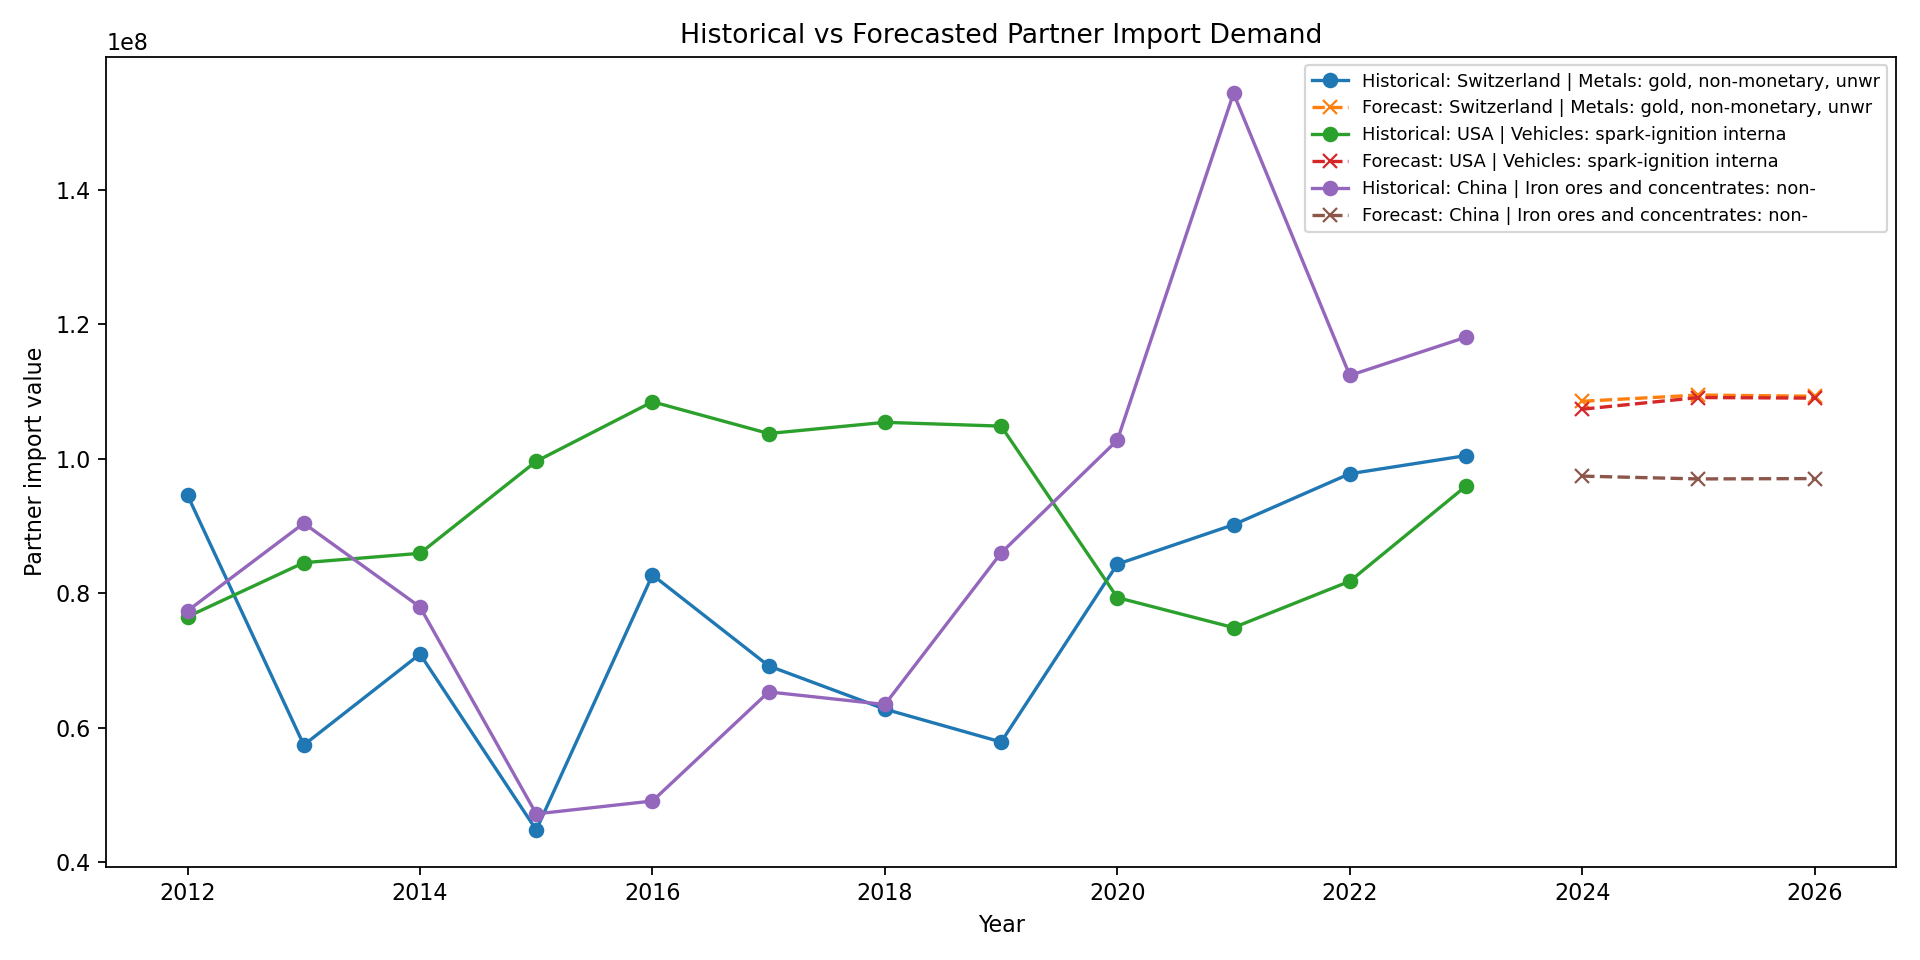

C:\Users\PC\Documents\machine-learning-project\machine-learning-project\data\forecast_outputs\plots\actual_vs_predicted_test_years.png


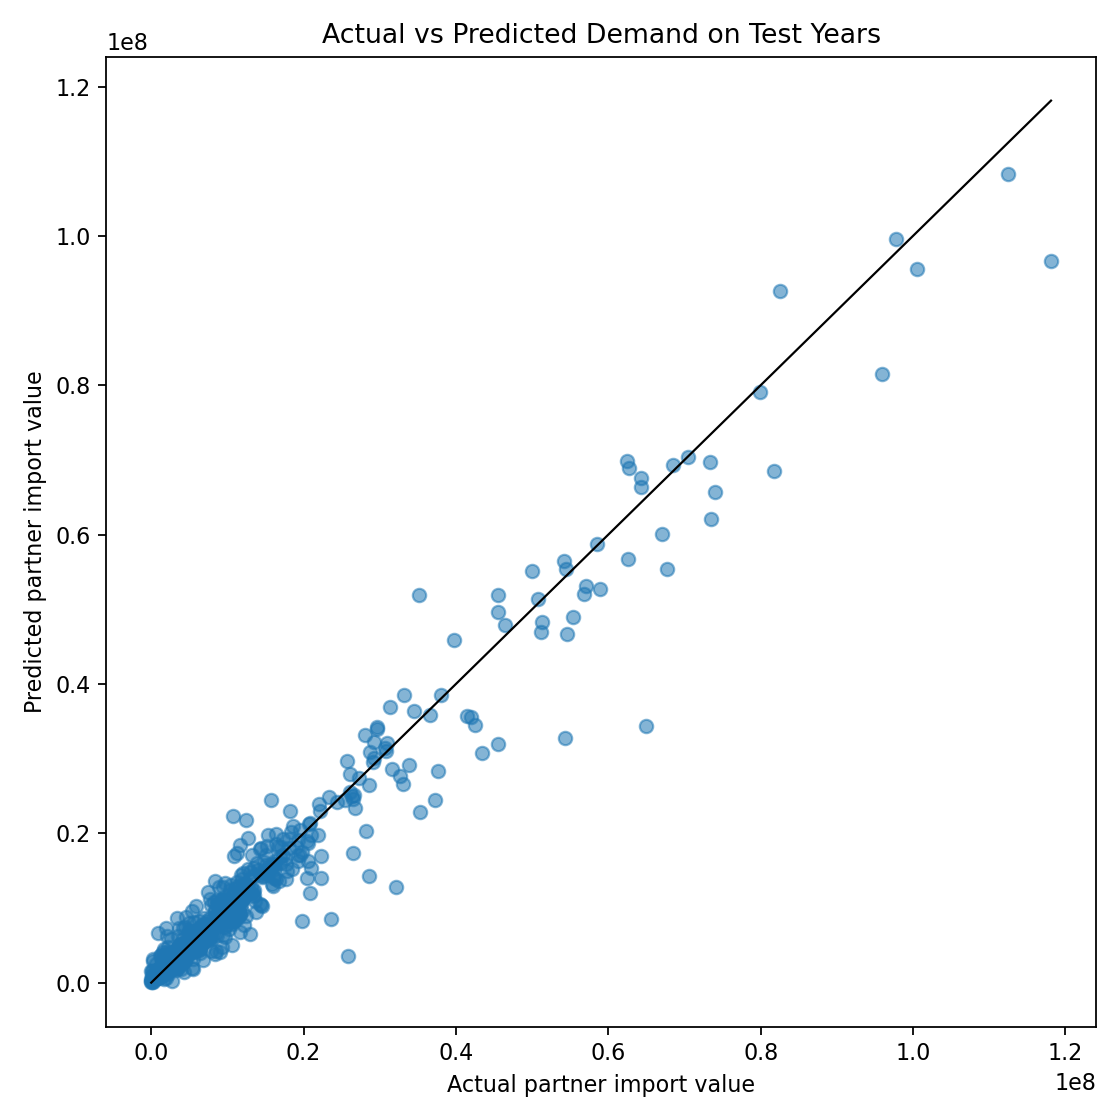

C:\Users\PC\Documents\machine-learning-project\machine-learning-project\data\forecast_outputs\plots\top_predicted_growth_countries.png


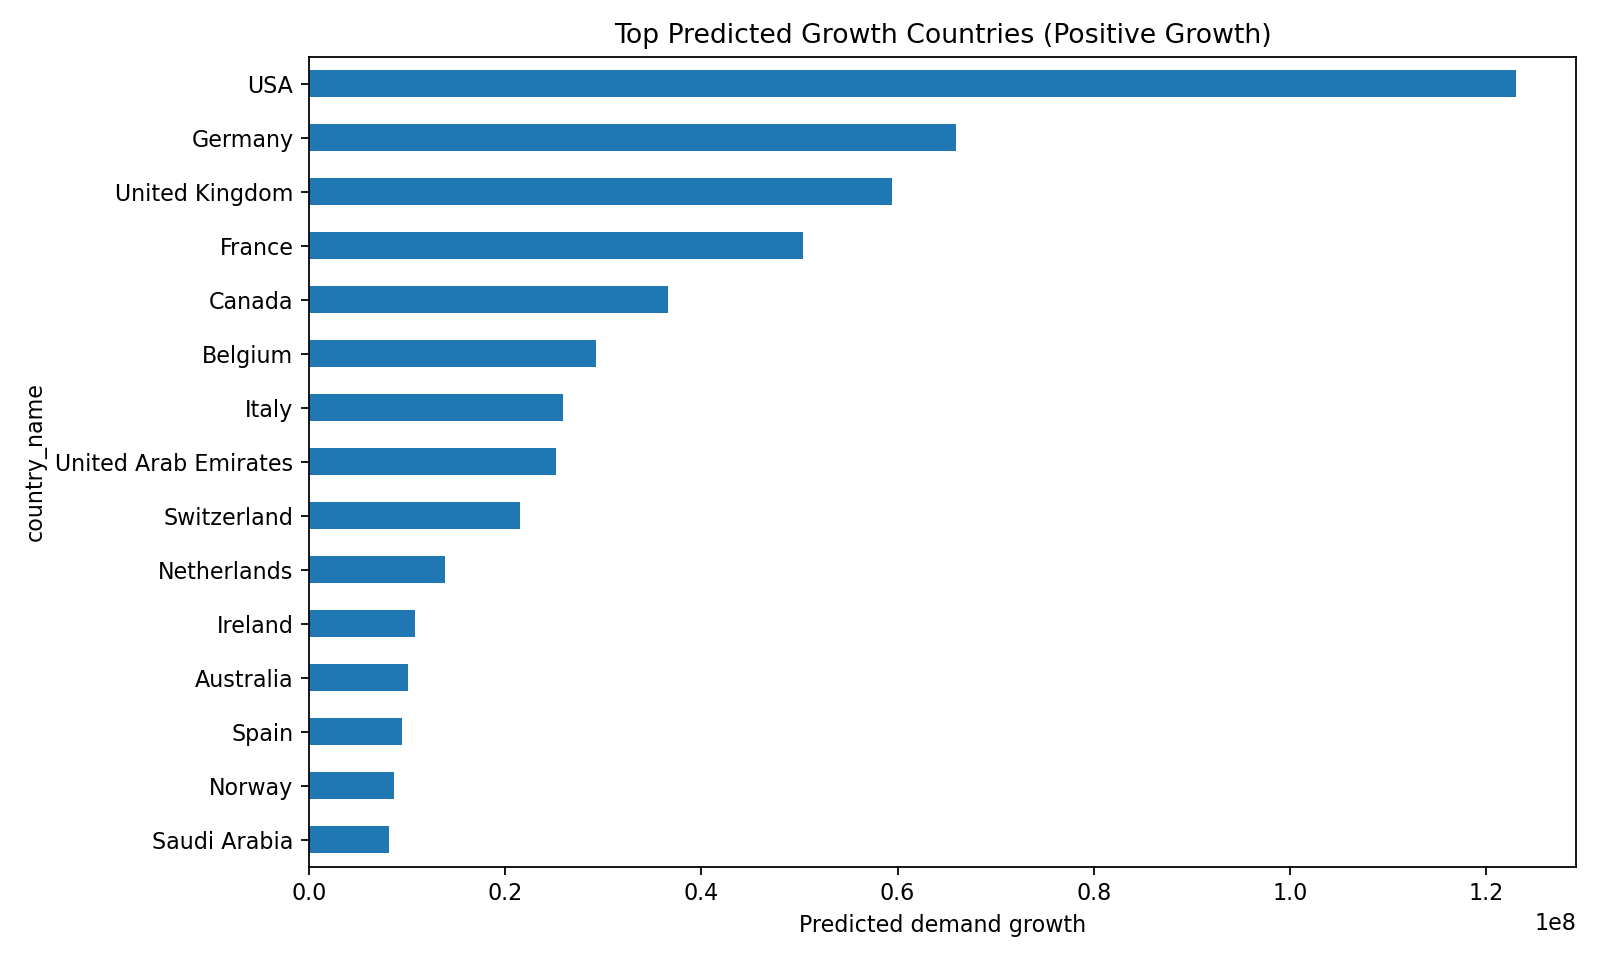

C:\Users\PC\Documents\machine-learning-project\machine-learning-project\data\forecast_outputs\plots\top_predicted_growth_products.png


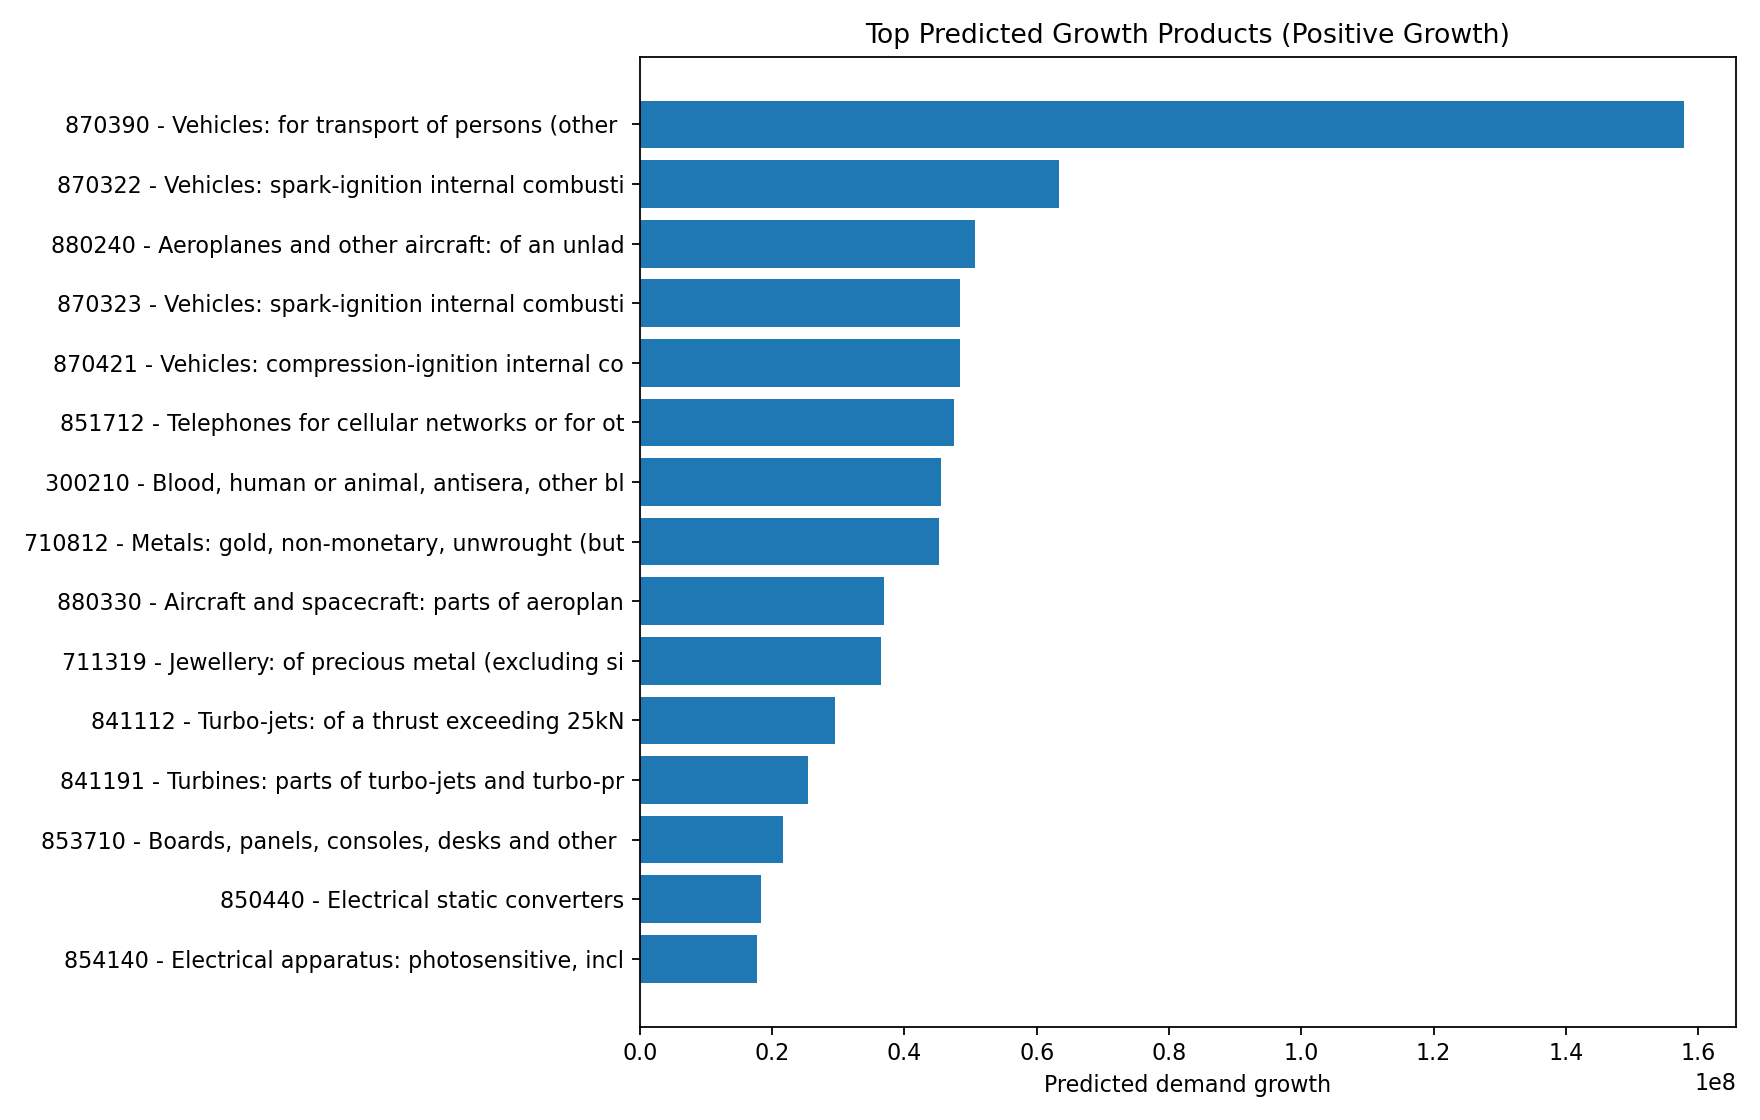

C:\Users\PC\Documents\machine-learning-project\machine-learning-project\data\forecast_outputs\plots\forecast_error_comparison_by_model.png


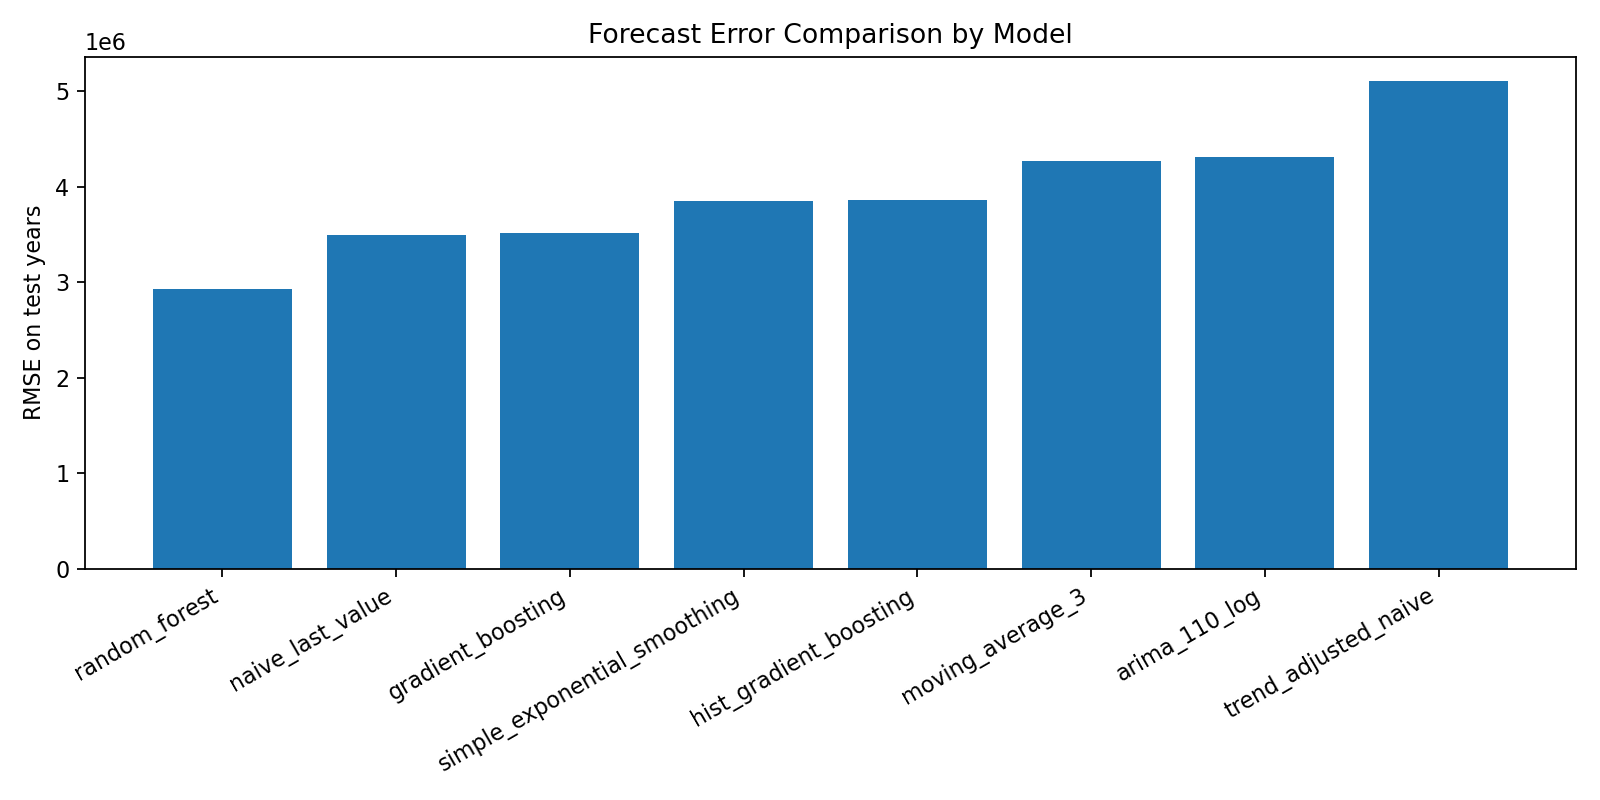

In [ ]:
from IPython.display import Image, display

plot_files = [
    "historical_vs_forecasted_demand.png",
    "actual_vs_predicted_test_years.png",
    "top_predicted_growth_countries.png",
    "top_predicted_growth_products.png",
    "forecast_error_comparison_by_model.png",
]

for plot_file in plot_files:
    path = OUTPUT_DIR / "plots" / plot_file
    print(path)
    display(Image(filename=str(path)))


## Limitations

The annual panel is short, with only 12 historical years. Forecasts should therefore be interpreted as directional demand signals, not exact trade predictions. The default non-hydrocarbon filter is intentionally strict because the project focuses on diversification. Some products containing the word `oils` may be excluded even if they are not mineral fuels; this can be relaxed later if the group wants a broader non-hydrocarbon definition.

The preliminary forecast outputs are ready for dashboard integration, but the final opportunity ranking should still combine forecasts with opportunity labels, market penetration, RCA, and Algeria-specific export context.
